In [80]:
# ------------------------------------------------------------
# 경고 제거
# ------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

import logging
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

# ============================================================
# 전자상거래 성과 분석 대시보드
# Google Colab 최종버전
# ============================================================

!apt-get -qq update
!apt-get -qq install fonts-nanum
!pip -q install openpyxl

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from google.colab import files

# ============================================================
# 한글 폰트 설정
# ============================================================

font_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"

fm.fontManager.addfont(font_path)

plt.rcParams["font.family"] = "NanumGothic"
plt.rcParams["axes.unicode_minus"] = False

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)


Saving B_1_소매판매액 시계열 분해를 통한 추세 및 계절성 분석.xlsx to B_1_소매판매액 시계열 분해를 통한 추세 및 계절성 분석 (8).xlsx


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


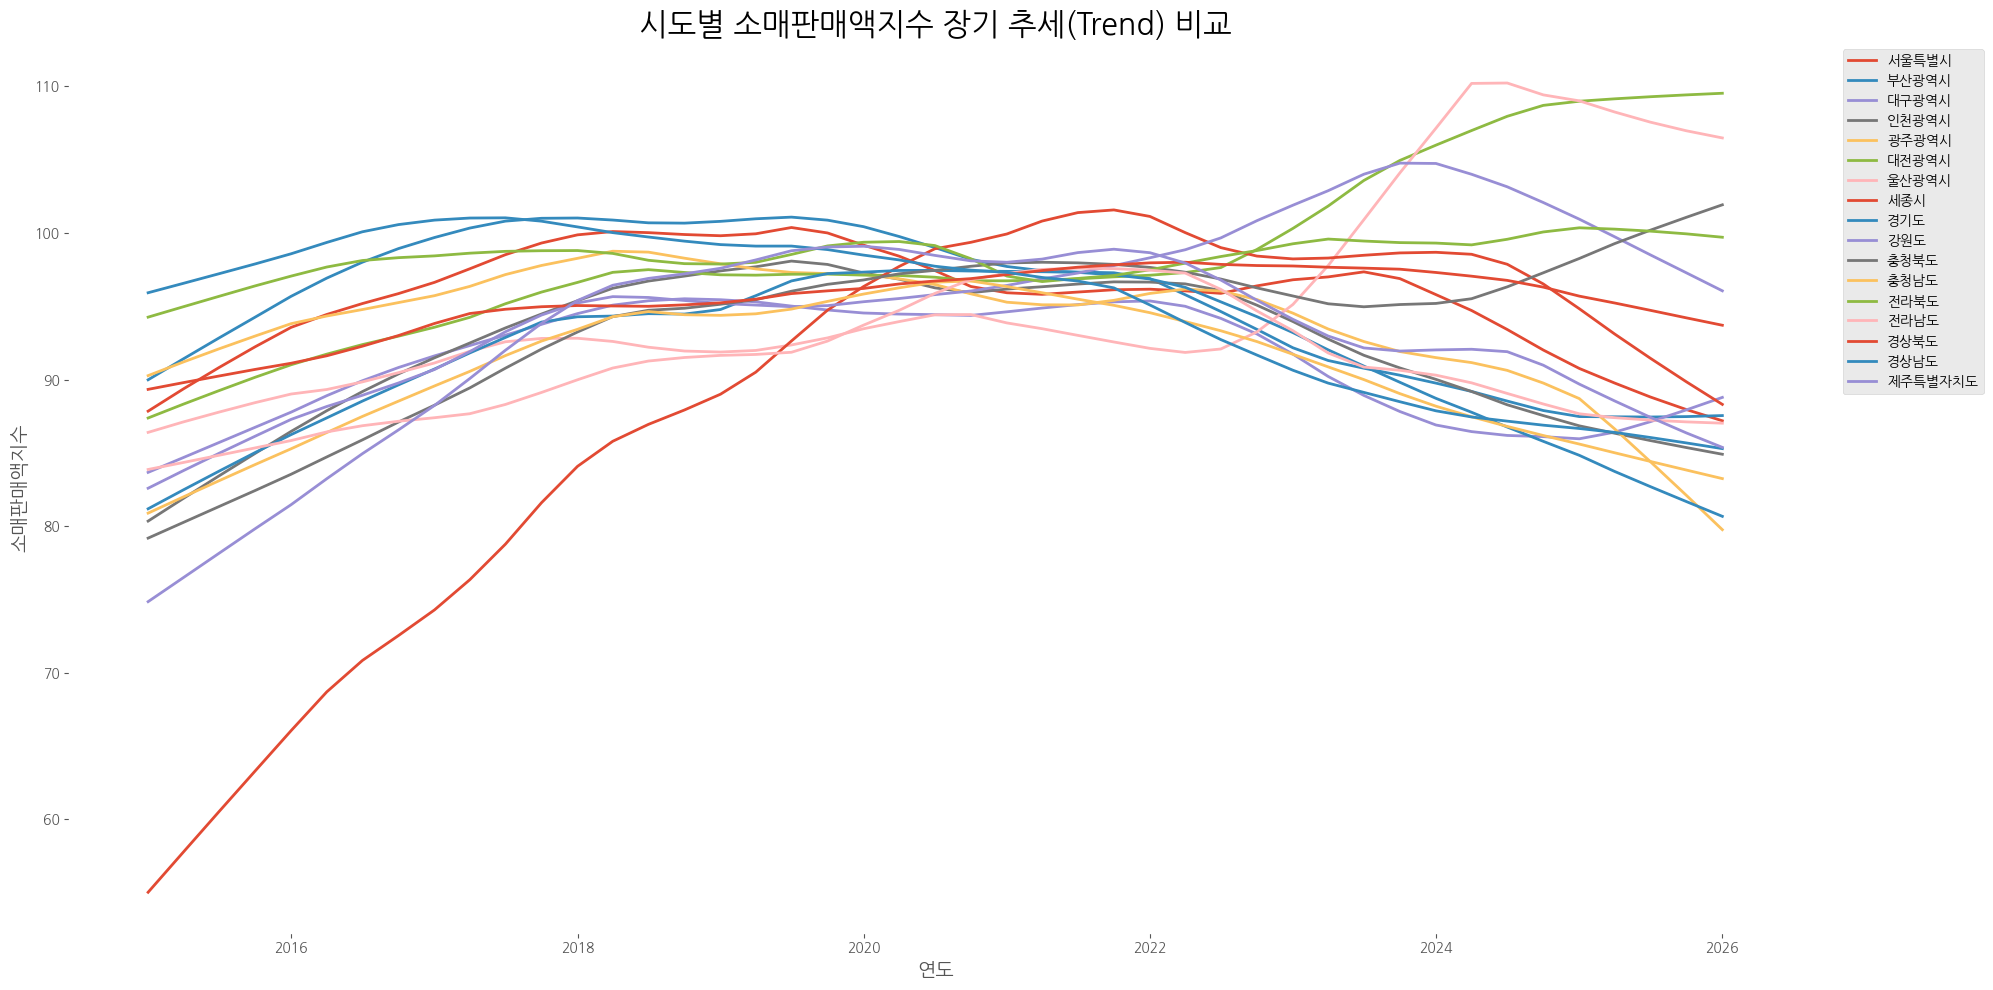



가장 많이 상승한 지역 TOP 3


,지역,초기값(2015.1/4),최종값(2026.1/4),변화율(%)
0,세종시,52.1,84.5,62.19
1,울산광역시,79.2,109.0,37.63
2,충청북도,73.2,94.6,29.23




가장 많이 하락한 지역 TOP 3


,지역,초기값(2015.1/4),최종값(2026.1/4),변화율(%)
0,경상남도,90.8,82.0,-9.69
1,광주광역시,84.0,76.9,-8.45
2,부산광역시,84.6,84.1,-0.59


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


분석 완료


In [22]:
# ============================================================
# 시도별 소매판매액지수 장기 추세(Trend) 분석
# ============================================================

!apt-get -qq install fonts-nanum

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

from google.colab import files
from IPython.display import display
from statsmodels.tsa.seasonal import STL

# ============================================================
# 한글 폰트
# ============================================================

font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_name = fm.FontProperties(fname=font_path).get_name()

plt.rc('font', family=font_name)
plt.rcParams['axes.unicode_minus'] = False

# ============================================================
# 파일 업로드
# ============================================================

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# ============================================================
# 데이터 읽기
# ============================================================

df = pd.read_excel(
    file_name,
    sheet_name='데이터'
)

# ============================================================
# 분기 컬럼 추출
# ============================================================

time_cols = list(df.columns[2:])

# ============================================================
# 날짜 생성
# ============================================================

dates = []

for col in time_cols:

    txt = str(col).replace(' p)', '')

    year = int(txt.split('.')[0])

    quarter = int(
        txt.split('.')[1].split('/')[0]
    )

    month = {
        1:1,
        2:4,
        3:7,
        4:10
    }[quarter]

    dates.append(
        pd.Timestamp(year, month, 1)
    )

# ============================================================
# STL Trend 계산
# ============================================================

trend_df = pd.DataFrame(index=dates)

result = []

for i in range(len(df)):

    region = df.iloc[i,0]

    series = pd.to_numeric(
        df.iloc[i,2:],
        errors='coerce'
    )

    series.index = dates

    stl = STL(
        series,
        period=4,
        robust=True
    )

    fit = stl.fit()

    trend = pd.Series(
        fit.trend,
        index=dates
    )

    trend_df[region] = trend

    # --------------------------------------------------------
    # 변화율 계산
    # 2015년 1분기 vs 2026년 1분기
    # --------------------------------------------------------

    start_value = float(series.iloc[0])
    end_value = float(series.iloc[-1])

    change_rate = (
        (end_value - start_value)
        / start_value
    ) * 100

    result.append([
        region,
        round(start_value,2),
        round(end_value,2),
        round(change_rate,2)
    ])

# ============================================================
# 변화율 DataFrame
# ============================================================

change_df = pd.DataFrame(
    result,
    columns=[
        '지역',
        '초기값(2015.1/4)',
        '최종값(2026.1/4)',
        '변화율(%)'
    ]
)

change_df = (
    change_df
    .sort_values(
        '변화율(%)',
        ascending=False
    )
    .reset_index(drop=True)
)

# ============================================================
# 상승 TOP3
# ============================================================

top3_up = change_df.head(3)

# ============================================================
# 하락 TOP3
# ============================================================

top3_down = (
    change_df
    .sort_values(
        '변화율(%)',
        ascending=True
    )
    .head(3)
    .reset_index(drop=True)
)

# ============================================================
# 그래프
# ============================================================

fig, ax = plt.subplots(
    figsize=(20,10),
    facecolor='none'
)

ax.set_facecolor('none')

for col in trend_df.columns:

    ax.plot(
        trend_df.index,
        trend_df[col],
        linewidth=2,
        label=col
    )

ax.set_title(
    '시도별 소매판매액지수 장기 추세(Trend) 비교',
    fontsize=22,
    fontweight='bold'
)

ax.set_xlabel(
    '연도',
    fontsize=14,
    fontweight='bold'
)

ax.set_ylabel(
    '소매판매액지수',
    fontsize=14,
    fontweight='bold'
)

ax.grid(
    True,
    linestyle='--',
    linewidth=0.8,
    alpha=0.7
)

ax.legend(
    bbox_to_anchor=(1.02,1),
    loc='upper left'
)

plt.tight_layout()

# 투명 PNG 저장
plt.savefig(
    '소매판매액지수_Trend.png',
    dpi=300,
    bbox_inches='tight',
    transparent=True
)

plt.show()

# ============================================================
# 상승 TOP3
# ============================================================

print("\n")
print("="*80)
print("가장 많이 상승한 지역 TOP 3")
print("="*80)

display(top3_up)

# ============================================================
# 하락 TOP3
# ============================================================

print("\n")
print("="*80)
print("가장 많이 하락한 지역 TOP 3")
print("="*80)

display(top3_down)

# ============================================================
# 결과 저장
# ============================================================

with pd.ExcelWriter(
    '소매판매액지수_Trend분석.xlsx'
) as writer:

    trend_df.to_excel(
        writer,
        sheet_name='Trend'
    )

    change_df.to_excel(
        writer,
        sheet_name='변화율분석',
        index=False
    )

    top3_up.to_excel(
        writer,
        sheet_name='상승TOP3',
        index=False
    )

    top3_down.to_excel(
        writer,
        sheet_name='하락TOP3',
        index=False
    )

files.download('소매판매액지수_Trend분석.xlsx')
files.download('소매판매액지수_Trend.png')

print("\n분석 완료")